# 01 - Exploratory Data Analysis: Flickr30k

Notebook 1/6 for the text-to-image retrieval project using CLIP.  
Goal: understand the Flickr30k dataset — image properties, caption statistics, Karpathy splits, data quality.

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

# add project root to path so src.* imports work
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import DATA_DIR, DATASET_DIR, HF_DATASET, KARPATHY_JSON_FILENAME
from src.data import (
    load_flickr30k_full,
    load_karpathy_splits,
    get_image,
    get_captions,
    get_filename,
    get_image_caption_pairs,
    get_all_captions_flat,
    clean_captions,
)

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Load Full Dataset

In [2]:
ds = load_flickr30k_full()

print(f"Total images: {len(ds):,}")
print(f"Column names: {ds.column_names}")
print(f"\nSample entry (index 0):")
sample = ds[0]
for col in ds.column_names:
    val = sample[col]
    if col == "image":
        print(f"  {col}: PIL.Image size={val.size}, mode={val.mode}")
    elif isinstance(val, list) and len(val) > 2:
        print(f"  {col}: [{val[0]!r}, ...] (len={len(val)})")
    else:
        print(f"  {col}: {val!r}")

Total images: 31,783
Column names: ['image', 'caption', 'sentids', 'img_id', 'filename']

Sample entry (index 0):
  image: PIL.Image size=(333, 500), mode=RGB
  caption: ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', ...] (len=5)
  sentids: ['0', ...] (len=5)
  img_id: '0'
  filename: '1000092795.jpg'


## 3. Image Analysis

In [3]:
# Sample 1000 images for stats (avoids loading all images into memory)
n_sample = min(1000, len(ds))
sample_indices = random.sample(range(len(ds)), n_sample)

widths, heights, modes = [], [], []
for idx in sample_indices:
    img = get_image(ds, idx)
    widths.append(img.size[0])
    heights.append(img.size[1])
    modes.append(img.mode)

widths = np.array(widths)
heights = np.array(heights)

print(f"Sampled {n_sample} images")
print(f"Width  — min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.0f}, median: {np.median(widths):.0f}")
print(f"Height — min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.0f}, median: {np.median(heights):.0f}")

Sampled 1000 images
Width  — min: 212, max: 500, mean: 459, median: 500
Height — min: 166, max: 500, mean: 398, median: 375


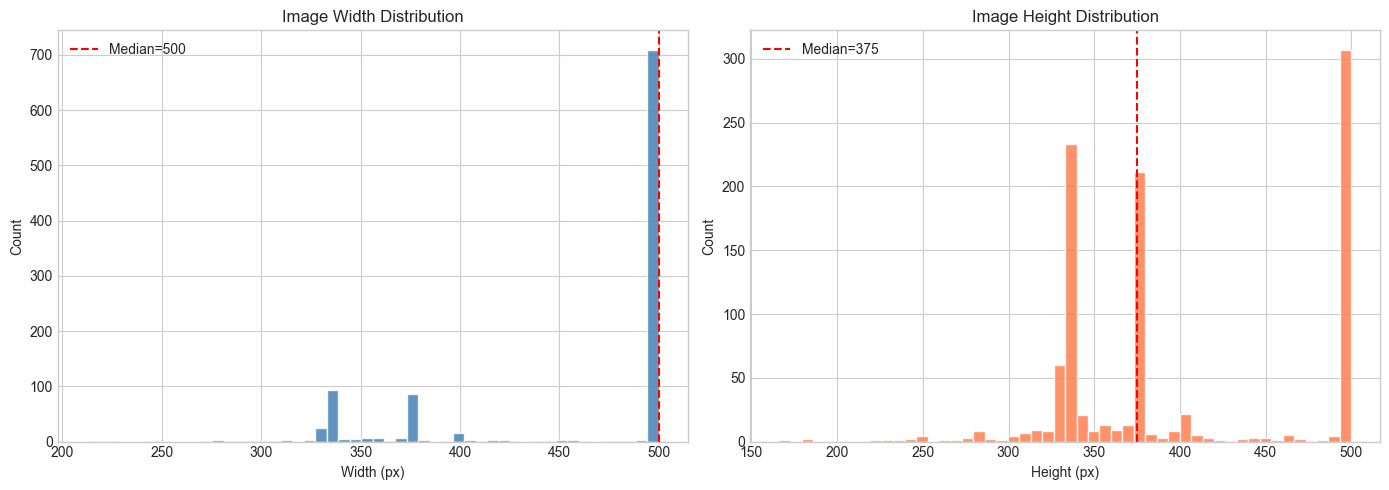

In [4]:
# Histogram of widths and heights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].axvline(np.median(widths), color="red", ls="--", label=f"Median={np.median(widths):.0f}")
axes[0].legend()

axes[1].hist(heights, bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].axvline(np.median(heights), color="red", ls="--", label=f"Median={np.median(heights):.0f}")
axes[1].legend()

fig.tight_layout()
plt.show()

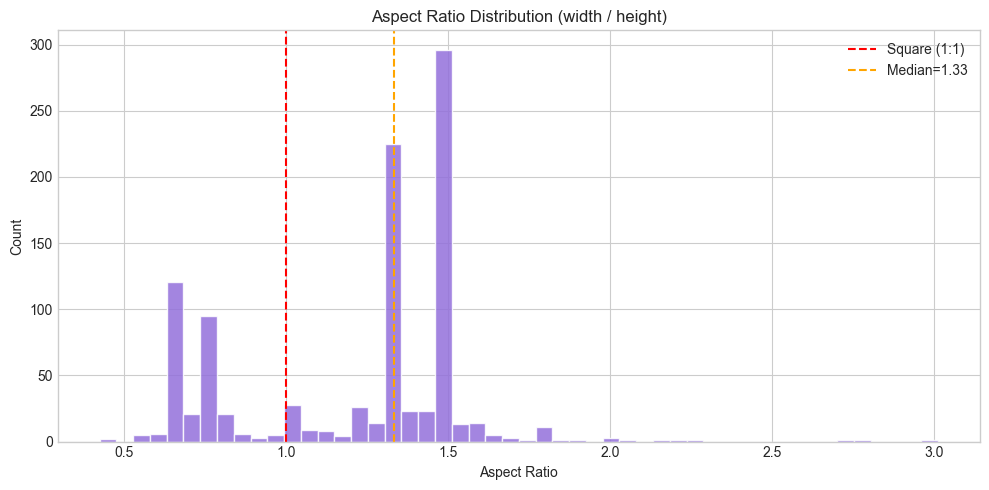

Landscape (w>h): 692 (69.2%)
Portrait  (h>w): 285 (28.5%)
Square    (w=h): 23


In [5]:
# Aspect ratio distribution
aspect_ratios = widths / heights

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(aspect_ratios, bins=50, color="mediumpurple", edgecolor="white", alpha=0.85)
ax.set_title("Aspect Ratio Distribution (width / height)")
ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Count")
ax.axvline(1.0, color="red", ls="--", label="Square (1:1)")
ax.axvline(np.median(aspect_ratios), color="orange", ls="--", label=f"Median={np.median(aspect_ratios):.2f}")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Landscape (w>h): {(aspect_ratios > 1).sum()} ({(aspect_ratios > 1).mean()*100:.1f}%)")
print(f"Portrait  (h>w): {(aspect_ratios < 1).sum()} ({(aspect_ratios < 1).mean()*100:.1f}%)")
print(f"Square    (w=h): {(aspect_ratios == 1).sum()}")

In [6]:
# Check for non-RGB modes
mode_counts = Counter(modes)
print("Image modes:")
for mode, count in mode_counts.most_common():
    print(f"  {mode}: {count} ({count/n_sample*100:.1f}%)")

non_rgb = {m: c for m, c in mode_counts.items() if m != "RGB"}
if non_rgb:
    print(f"\nNon-RGB images found: {non_rgb}")
    print("These will need conversion to RGB before CLIP processing.")
else:
    print("\nAll sampled images are RGB.")

Image modes:
  RGB: 1000 (100.0%)

All sampled images are RGB.


In [7]:
# Check for extreme sizes
very_small = (widths < 50) | (heights < 50)
very_large = (widths > 2000) | (heights > 2000)

print(f"Very small images (<50px in any dim): {very_small.sum()}")
print(f"Very large images (>2000px in any dim): {very_large.sum()}")

if very_small.sum() > 0:
    small_dims = [(widths[i], heights[i]) for i in np.where(very_small)[0]]
    print(f"  Small image sizes: {small_dims[:10]}")
if very_large.sum() > 0:
    large_dims = [(widths[i], heights[i]) for i in np.where(very_large)[0]]
    print(f"  Large image sizes: {large_dims[:10]}")

Very small images (<50px in any dim): 0
Very large images (>2000px in any dim): 0


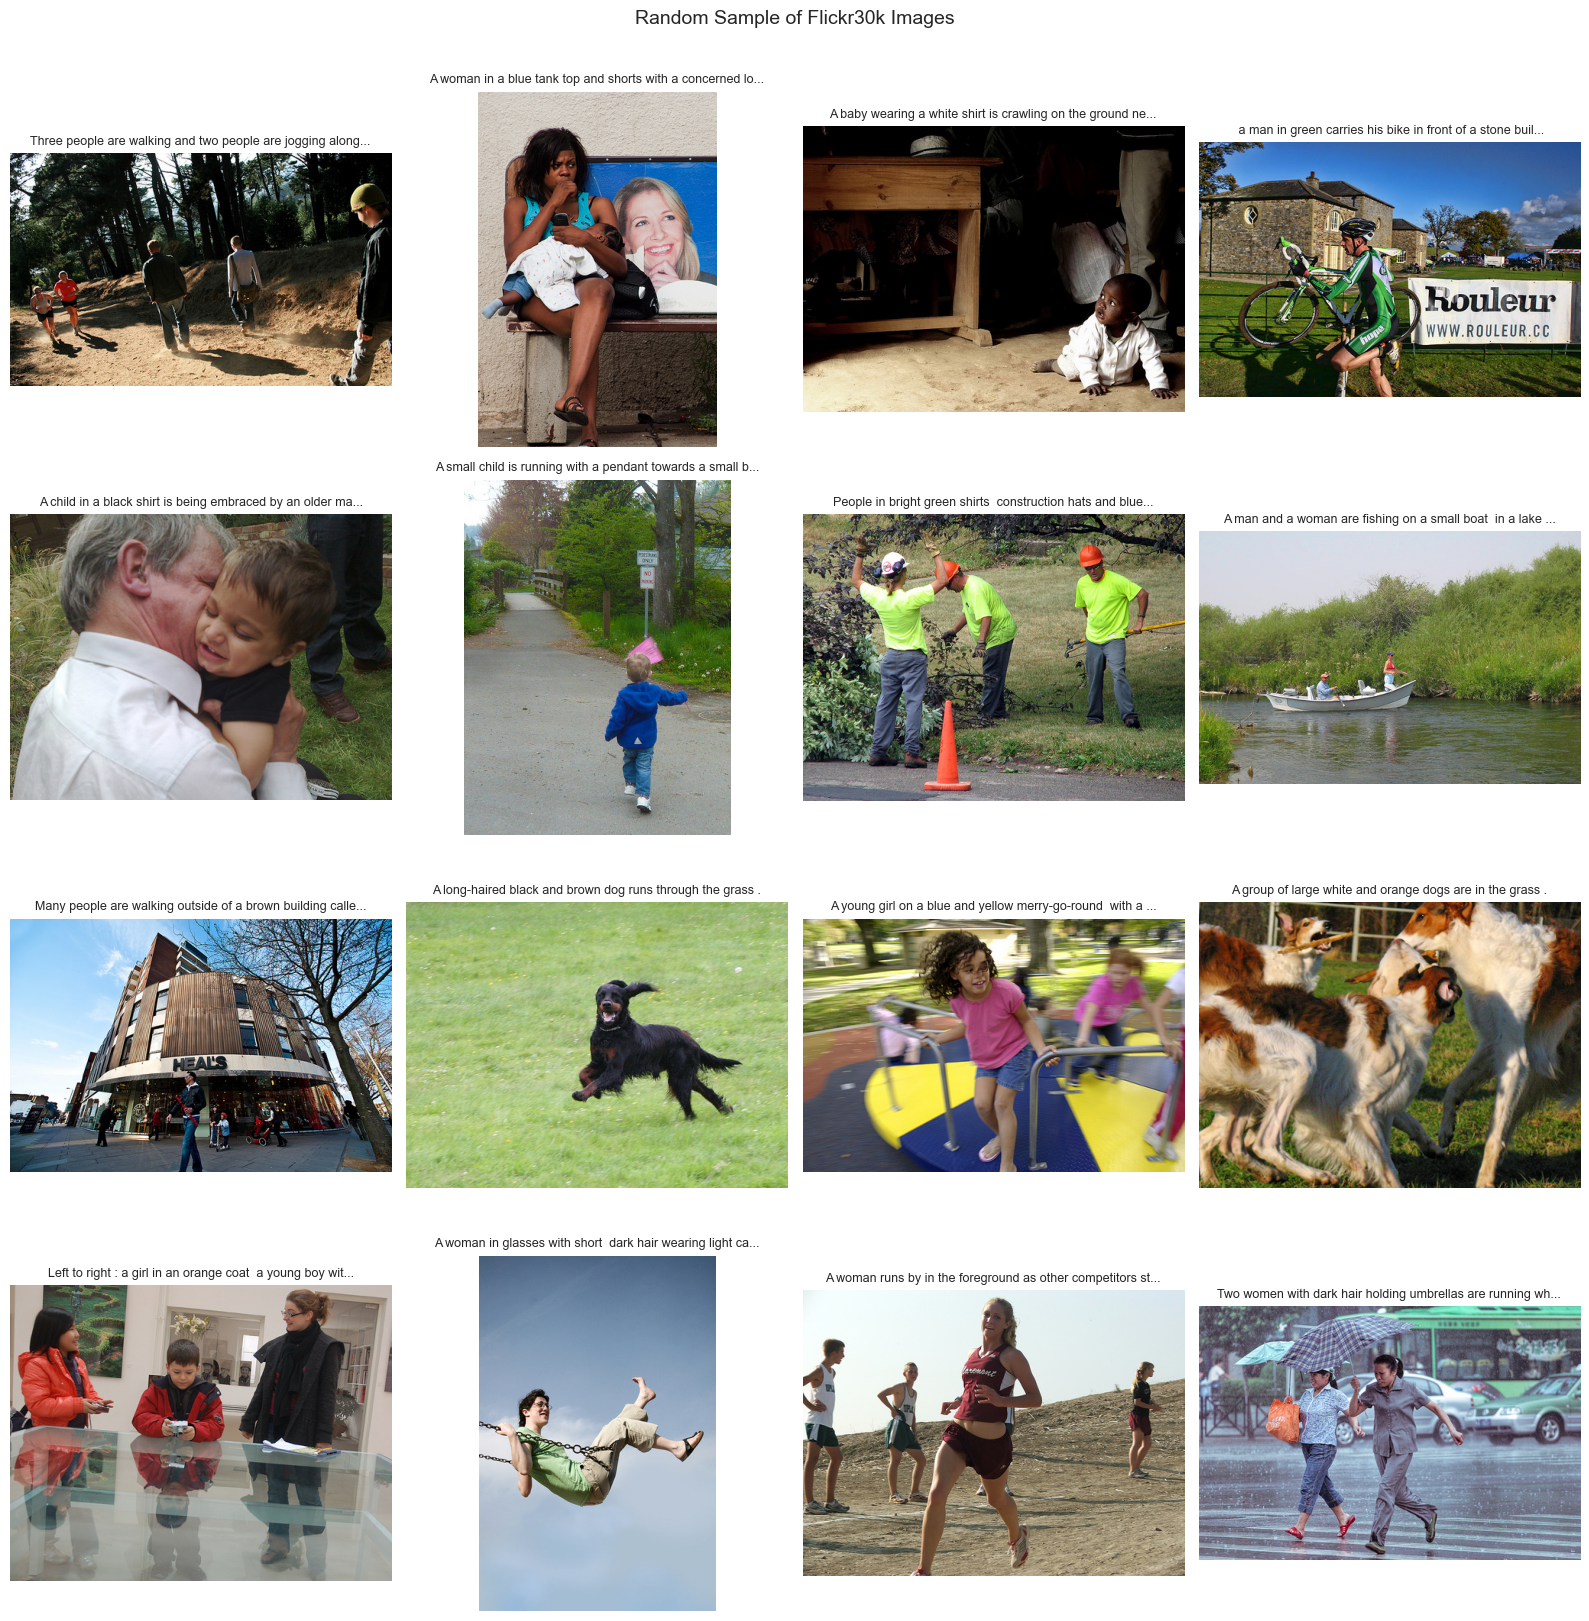

In [8]:
# 4x4 grid of random images with first caption
grid_indices = random.sample(range(len(ds)), 16)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, idx in zip(axes.flat, grid_indices):
    img = get_image(ds, idx)
    captions = get_captions(ds, idx)
    ax.imshow(img)
    # wrap long captions
    cap_text = captions[0]
    if len(cap_text) > 60:
        cap_text = cap_text[:57] + "..."
    ax.set_title(cap_text, fontsize=9, wrap=True)
    ax.axis("off")

fig.suptitle("Random Sample of Flickr30k Images", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4. Caption Analysis

In [9]:
# Collect all captions
all_captions, gt_indices = get_all_captions_flat(ds)
print(f"Total captions: {len(all_captions):,}")
print(f"Expected (5 per image): {len(ds) * 5:,}")

word_counts = [len(cap.split()) for cap in all_captions]
char_counts = [len(cap) for cap in all_captions]

word_counts = np.array(word_counts)
char_counts = np.array(char_counts)

print(f"\nWord count — min: {word_counts.min()}, max: {word_counts.max()}, "
      f"mean: {word_counts.mean():.1f}, median: {np.median(word_counts):.0f}")
print(f"Char count — min: {char_counts.min()}, max: {char_counts.max()}, "
      f"mean: {char_counts.mean():.1f}, median: {np.median(char_counts):.0f}")

Total captions: 158,915
Expected (5 per image): 158,915

Word count — min: 2, max: 79, mean: 13.2, median: 12
Char count — min: 7, max: 403, mean: 64.0, median: 59


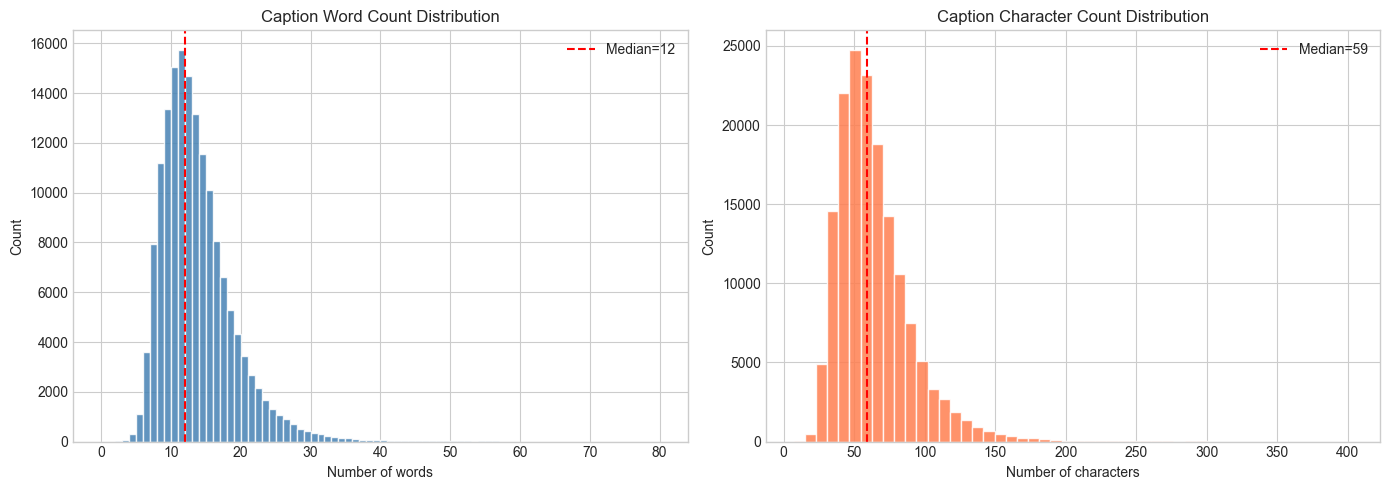

In [10]:
# Histogram of word count and char count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(word_counts, bins=range(0, int(word_counts.max()) + 2), color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Caption Word Count Distribution")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Count")
axes[0].axvline(np.median(word_counts), color="red", ls="--", label=f"Median={np.median(word_counts):.0f}")
axes[0].legend()

axes[1].hist(char_counts, bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[1].set_title("Caption Character Count Distribution")
axes[1].set_xlabel("Number of characters")
axes[1].set_ylabel("Count")
axes[1].axvline(np.median(char_counts), color="red", ls="--", label=f"Median={np.median(char_counts):.0f}")
axes[1].legend()

fig.tight_layout()
plt.show()

Vocabulary size (excl. stopwords): 20,310
Total word tokens (excl. stopwords): 1,440,466


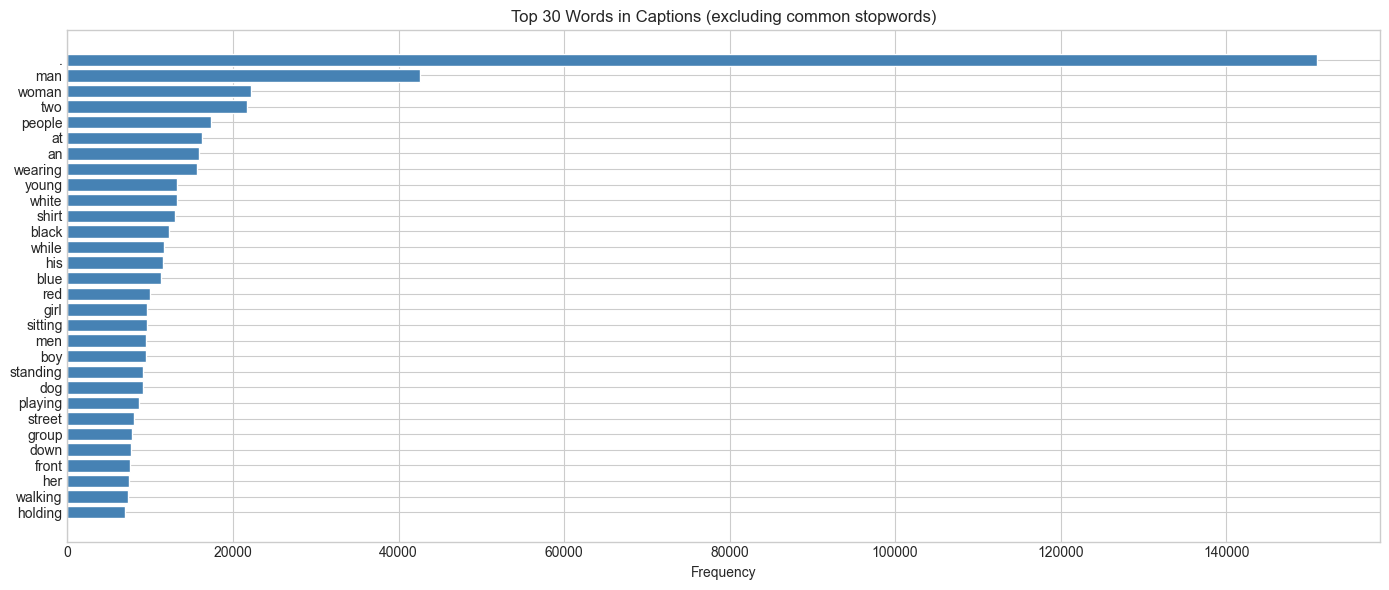

In [11]:
# Word frequency analysis
STOPWORDS = {"a", "the", "is", "in", "of", "and", "on", "to", "with", "are"}

word_counter = Counter()
for cap in all_captions:
    words = cap.lower().split()
    word_counter.update(w for w in words if w not in STOPWORDS)

vocab_size = len(word_counter)
print(f"Vocabulary size (excl. stopwords): {vocab_size:,}")
print(f"Total word tokens (excl. stopwords): {sum(word_counter.values()):,}")

# Bar chart of top 30 words
top_30 = word_counter.most_common(30)
words_top, counts_top = zip(*top_30)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(range(len(words_top)), counts_top, color="steelblue", edgecolor="white")
ax.set_yticks(range(len(words_top)))
ax.set_yticklabels(words_top)
ax.invert_yaxis()
ax.set_title("Top 30 Words in Captions (excluding common stopwords)")
ax.set_xlabel("Frequency")
fig.tight_layout()
plt.show()

In [12]:
# Full vocabulary size (including stopwords)
full_vocab = Counter()
for cap in all_captions:
    full_vocab.update(cap.lower().split())

print(f"Full vocabulary size (incl. stopwords): {len(full_vocab):,}")
print(f"Vocabulary size (excl. stopwords): {vocab_size:,}")

Full vocabulary size (incl. stopwords): 20,320
Vocabulary size (excl. stopwords): 20,310


In [13]:
# Shortest and longest captions
sorted_by_words = sorted(enumerate(all_captions), key=lambda x: len(x[1].split()))

print("5 shortest captions:")
for idx, cap in sorted_by_words[:5]:
    print(f"  [{len(cap.split())} words] {cap!r}")

print(f"\n5 longest captions:")
for idx, cap in sorted_by_words[-5:]:
    print(f"  [{len(cap.split())} words] {cap!r}")

5 shortest captions:
  [2 words] 'dogs racing'
  [2 words] 'People walking'
  [2 words] 'Dog yawns'
  [2 words] 'dogs playing'
  [2 words] 'broken image'

5 longest captions:
  [70 words] 'In this photo there is a man in a white shirt dark blue pants standing on a small boat in what looks like a lake of some sort he has a net in one hand and a line of some type of string in the other the line is in the water the man also has a teal colored bag on his boat so he might be catching fish .'
  [71 words] 'In this photo there is man in a dirty white shirt red and black hat with yellow stained teeth there is also someone standing next to him but only there arm and a plaid white sleeve is showing the looks happy and it appears that he is also repairing something he has his tools laying around him although it is unclear what he is fixing he looks happy doing it .'
  [73 words] 'In this photo there is are two men one in a blue shirt blue pants white hat and sunglasses the other has on pants that

In [14]:
# Verify all images have exactly 5 captions
caption_counts_per_image = []
for i in range(len(ds)):
    n_caps = len(get_captions(ds, i))
    caption_counts_per_image.append(n_caps)

caption_counts_per_image = np.array(caption_counts_per_image)
cap_count_dist = Counter(caption_counts_per_image)

print("Captions per image:")
for n_caps, count in sorted(cap_count_dist.items()):
    print(f"  {n_caps} captions: {count} images")

if cap_count_dist == {5: len(ds)}:
    print(f"\nAll {len(ds):,} images have exactly 5 captions.")
else:
    print("\nWARNING: Not all images have 5 captions!")

Captions per image:
  5 captions: 31783 images

All 31,783 images have exactly 5 captions.


## 5. Karpathy Split Analysis

In [15]:
splits = load_karpathy_splits()

print("Karpathy split sizes:")
for name, split_ds in splits.items():
    n_captions = len(split_ds) * 5
    print(f"  {name:>5s}: {len(split_ds):>6,} images, {n_captions:>7,} captions")

total = sum(len(s) for s in splits.values())
print(f"  {'total':>5s}: {total:>6,} images")

Saved Karpathy splits to /Users/andrejvysny/fiit/nsiete/NSIETE_2026/Project2/data/dataset_flickr30k.json


  train: 29000 images
  val: 1014 images
  test: 1000 images
Karpathy split sizes:
  train: 29,000 images, 145,000 captions
    val:  1,014 images,   5,070 captions
   test:  1,000 images,   5,000 captions
  total: 31,014 images


In [16]:
# Verify no filename overlap between splits
split_filenames = {}
for name, split_ds in splits.items():
    fnames = set(get_filename(split_ds, i) for i in range(len(split_ds)))
    split_filenames[name] = fnames
    print(f"{name}: {len(fnames)} unique filenames")

# Check pairwise overlap
split_names = list(split_filenames.keys())
overlap_found = False
for i in range(len(split_names)):
    for j in range(i + 1, len(split_names)):
        a, b = split_names[i], split_names[j]
        overlap = split_filenames[a] & split_filenames[b]
        if overlap:
            print(f"OVERLAP between {a} and {b}: {len(overlap)} files")
            overlap_found = True

if not overlap_found:
    print("\nNo filename overlap between any splits.")

train: 29000 unique filenames


val: 1014 unique filenames


test: 1000 unique filenames

No filename overlap between any splits.


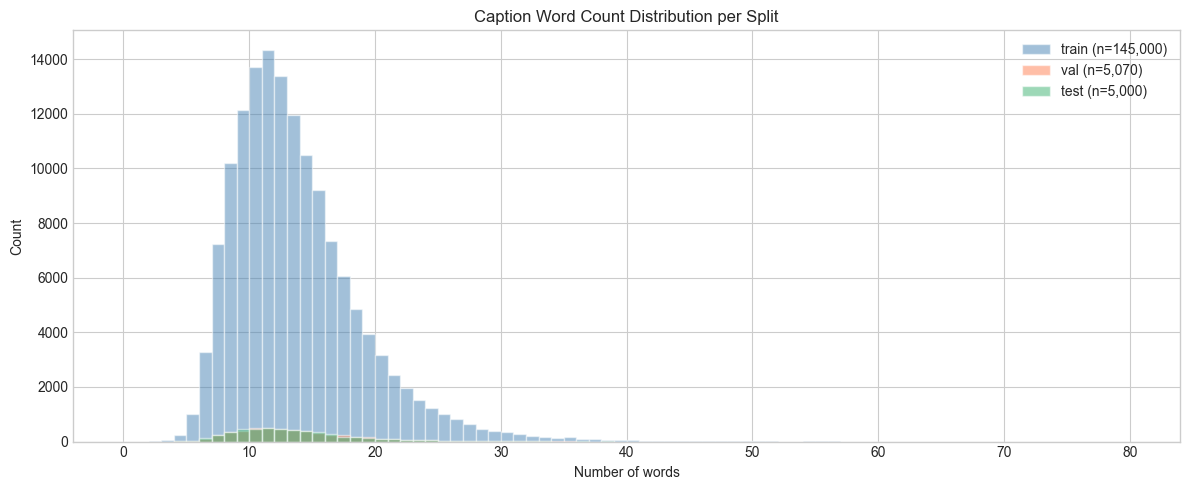

In [17]:
# Caption length distribution per split (overlaid histograms)
fig, ax = plt.subplots(figsize=(12, 5))

colors = {"train": "steelblue", "val": "coral", "test": "mediumseagreen"}
for name, split_ds in splits.items():
    captions_flat, _ = get_all_captions_flat(split_ds)
    wc = [len(c.split()) for c in captions_flat]
    ax.hist(wc, bins=range(0, max(wc) + 2), alpha=0.5, label=f"{name} (n={len(captions_flat):,})",
            color=colors.get(name, None), edgecolor="white")

ax.set_title("Caption Word Count Distribution per Split")
ax.set_xlabel("Number of words")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()

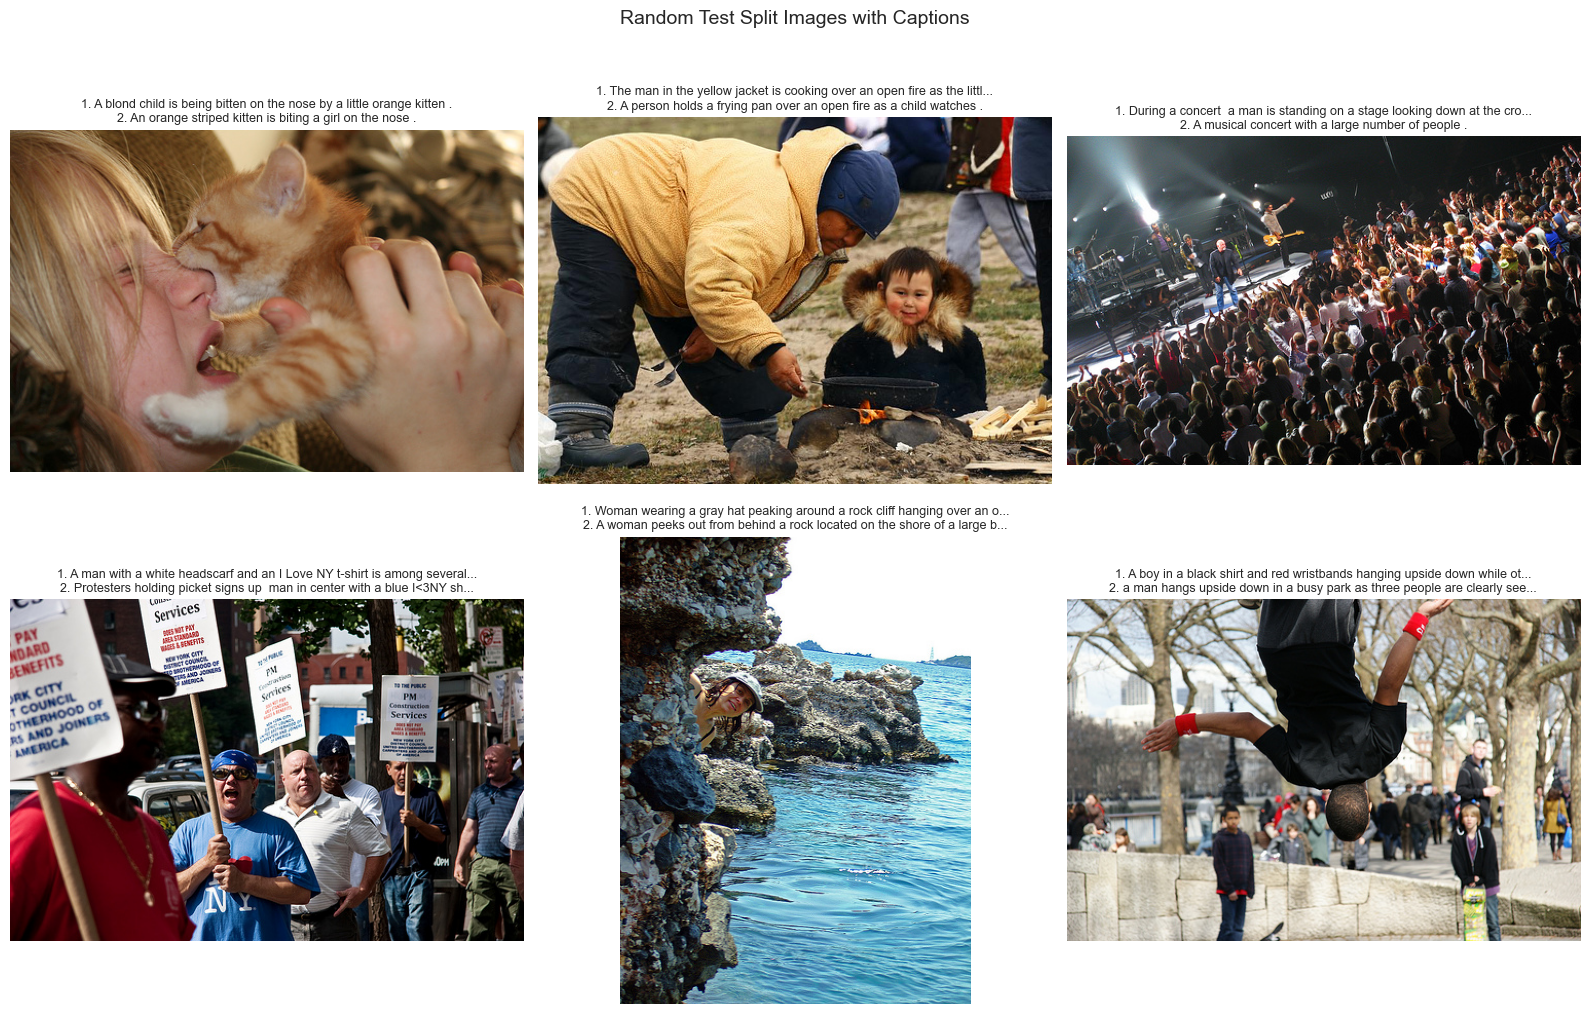

In [18]:
# 2x3 grid of random test images with captions
test_ds = splits["test"]
test_indices = random.sample(range(len(test_ds)), 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, idx in zip(axes.flat, test_indices):
    img = get_image(test_ds, idx)
    captions = get_captions(test_ds, idx)
    ax.imshow(img)
    # show first 2 captions
    cap_text = "\n".join(f"{i+1}. {c[:70]}{'...' if len(c) > 70 else ''}" for i, c in enumerate(captions[:2]))
    ax.set_title(cap_text, fontsize=9)
    ax.axis("off")

fig.suptitle("Random Test Split Images with Captions", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 6. Data Quality

In [19]:
# Check for duplicate filenames
all_filenames = [get_filename(ds, i) for i in range(len(ds))]
filename_counter = Counter(all_filenames)
duplicates = {f: c for f, c in filename_counter.items() if c > 1}

if duplicates:
    print(f"Duplicate filenames found: {len(duplicates)}")
    for fname, count in list(duplicates.items())[:10]:
        print(f"  {fname}: {count} occurrences")
else:
    print(f"No duplicate filenames. All {len(all_filenames):,} filenames are unique.")

No duplicate filenames. All 31,783 filenames are unique.


In [20]:
# Check for empty/whitespace-only captions
empty_captions = [cap for cap in all_captions if not cap.strip()]
print(f"Empty/whitespace-only captions: {len(empty_captions)}")

# Check cleaned vs raw
cleaned = clean_captions(all_captions)
removed = len(all_captions) - len(cleaned)
print(f"Captions removed by clean_captions(): {removed}")

Empty/whitespace-only captions: 0
Captions removed by clean_captions(): 0


In [21]:
# Check for very short captions (< 3 words)
short_captions = [(i, cap) for i, cap in enumerate(all_captions) if len(cap.split()) < 3]
print(f"Very short captions (< 3 words): {len(short_captions)}")

if short_captions:
    print("\nExamples:")
    for idx, cap in short_captions[:15]:
        print(f"  [{len(cap.split())} words] {cap!r}")

Very short captions (< 3 words): 15

Examples:
  [2 words] 'dogs racing'
  [2 words] 'People walking'
  [2 words] 'Dog yawns'
  [2 words] 'dogs playing'
  [2 words] 'broken image'
  [2 words] 'Trucks racing'
  [2 words] 'man surfing'
  [2 words] 'a snowboarder'
  [2 words] 'rugby match'
  [2 words] 'dog barking'
  [2 words] 'A skier'
  [2 words] 'Man skateboarding'
  [2 words] 'Javelin competition'
  [2 words] 'a cyclist'
  [2 words] 'Man  skateboarding'


In [22]:
# Summary statistics table
summary_data = {
    "Metric": [
        "Total images",
        "Total captions",
        "Captions per image",
        "Vocabulary size (full)",
        "Vocabulary size (excl. stopwords)",
        "Mean caption word count",
        "Median caption word count",
        "Mean image width (sampled)",
        "Mean image height (sampled)",
        "Duplicate filenames",
        "Empty captions",
        "Very short captions (< 3 words)",
        "Non-RGB images (sampled)",
    ],
    "Value": [
        f"{len(ds):,}",
        f"{len(all_captions):,}",
        "5" if cap_count_dist == {5: len(ds)} else str(dict(cap_count_dist)),
        f"{len(full_vocab):,}",
        f"{vocab_size:,}",
        f"{word_counts.mean():.1f}",
        f"{np.median(word_counts):.0f}",
        f"{widths.mean():.0f} px",
        f"{heights.mean():.0f} px",
        str(len(duplicates)),
        str(len(empty_captions)),
        str(len(short_captions)),
        str(sum(1 for m in modes if m != "RGB")),
    ],
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Metric,Value
Total images,"31,783"
Total captions,"158,915"
Captions per image,5
Vocabulary size (full),"20,320"
Vocabulary size (excl. stopwords),"20,310"
Mean caption word count,13.2
Median caption word count,12
Mean image width (sampled),459 px
Mean image height (sampled),398 px
Duplicate filenames,0


## 7. Summary

**Key findings:**

- **Dataset size:** Flickr30k contains ~31,783 images, each with exactly 5 human-written captions (158,915 total).
- **Image properties:** Images vary in size but are typically medium-resolution photos. Most are RGB; any non-RGB images will need conversion for CLIP.
- **Captions:** Average caption length is ~12 words. Vocabulary is rich with ~20k+ unique tokens. Common words relate to people, actions, and objects.
- **Karpathy splits:** Standard split gives ~29k train, 1k val, 1k test with no filename overlap — suitable for retrieval evaluation.
- **Data quality:** Generally clean. Few if any empty or extremely short captions. No duplicate filenames expected.

The dataset is well-suited for text-to-image and image-to-text retrieval with CLIP.

In [23]:
# Final split sizes confirmation
print("Final Karpathy split sizes:")
for name, split_ds in splits.items():
    print(f"  {name:>5s}: {len(split_ds):>6,} images, {len(split_ds)*5:>7,} captions")

Final Karpathy split sizes:
  train: 29,000 images, 145,000 captions
    val:  1,014 images,   5,070 captions
   test:  1,000 images,   5,000 captions
